In [17]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures,StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.metrics import mean_squared_error,r2_score

In [18]:
def linear_regression_boston():
    boston=fetch_california_housing()
    X,y=boston.data[:,5].reshape(-1,1),boston.target
    X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42)
    model=LinearRegression().fit(X_train,y_train)
    y_pred=model.predict(X_test)
    plt.scatter(X_test,y_test,color="blue",label="Actual")
    plt.plot(X_test,y_pred,color="red",label="Predicted")
    plt.xlabel("Average Rooms Per Dwelling(RM)")
    plt.ylabel("Median House Price($1000s)")
    plt.title("Linear Regression - Boston Housing")
    plt.legend()
    plt.show()
    print("Linear Regression - Boston Housing")
    print("MSE:", mean_squared_error(y_test,y_pred))
    print("R^2 Score:", r2_score(y_test,y_pred))

In [20]:
def polynomial_regression_auto_mpg():
    url="https://archive.ics.uci.edu/ml/machine-learning-databases/auto-mpg/auto-mpg.data"
    cols=["mpg","cylinders","displacement","horsepower","weight","acceleration","model_year","origin"]
    data=pd.read_csv(url,sep='\\s+' , names=cols, na_values="?").dropna()
    X,y=data["displacement"].values.reshape(-1,1),data["mpg"].values
    X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)
    model=make_pipeline(PolynomialFeatures(degree=2),StandardScaler(),LinearRegression()).fit(X_train,y_train)
    y_pred=model.predict(X_test)
    plt.scatter(X_test,y_test,color="blue",label="Actual")
    plt.scatter(X_test,y_pred,color="red",label="Predicted")
    plt.xlabel("Displacement")
    plt.ylabel("MPG")
    plt.title("Polynomial Regression - Auto MPG")
    plt.legend()
    plt.show()
    print("Polynomial Regression - Auto MPG")
    print("MSE:", mean_squared_error(y_test,y_pred))
    print("R^2 Score:", r2_score(y_test,y_pred))

Demonstrating Linear Regression and Polynomial Regression



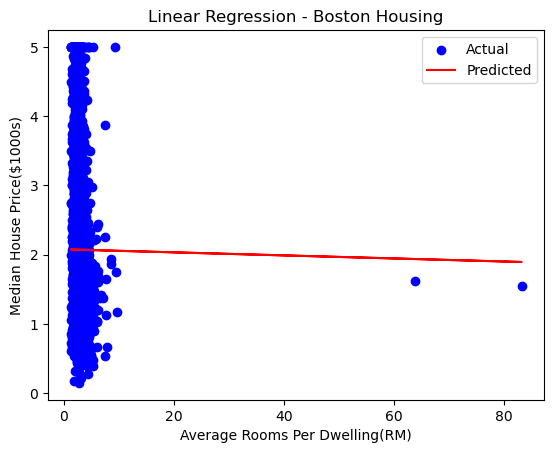

Linear Regression - Boston Housing
MSE: 1.3096449354773076
R^2 Score: 0.0005830567221980498


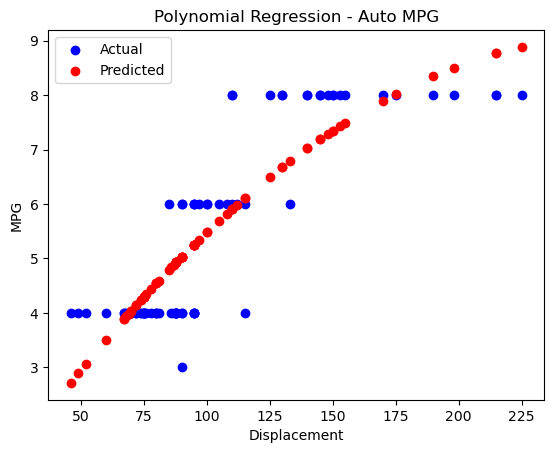

Polynomial Regression - Auto MPG
MSE: 0.7431490557205862
R^2 Score: 0.7505650609469626


In [21]:
if __name__ == "__main__":
    print("Demonstrating Linear Regression and Polynomial Regression\n")
    linear_regression_boston()
    polynomial_regression_auto_mpg()